# 非线性系统回归预测模型训练

## 任务：多输入多输出非线性系统映射学习
## 架构：MLP（多层感知机） + LSTM（时序记忆网络）
## 目标：R² ≥ 0.50


In [1]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np, os, sys
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import seaborn as sns

# Auto-detect project root
def get_project_root():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.exists(os.path.join(current, 'backend')) and os.path.exists(os.path.join(current, 'dataset')):
            return current
        parent = os.path.dirname(current)
        if parent == current: break
        current = parent
    return os.getcwd()
ROOT = get_project_root()
print(f'Project root: {ROOT}')

sys.path.insert(0, os.path.join(ROOT, 'backend', 'regression_model'))
from model import get_model

import warnings as _w; _w.filterwarnings('ignore', category=UserWarning)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Project root: C:\Users\DOVE\python学习\大二下实训
Device: cuda


X: (5000, 3), Y: (5000, 3)


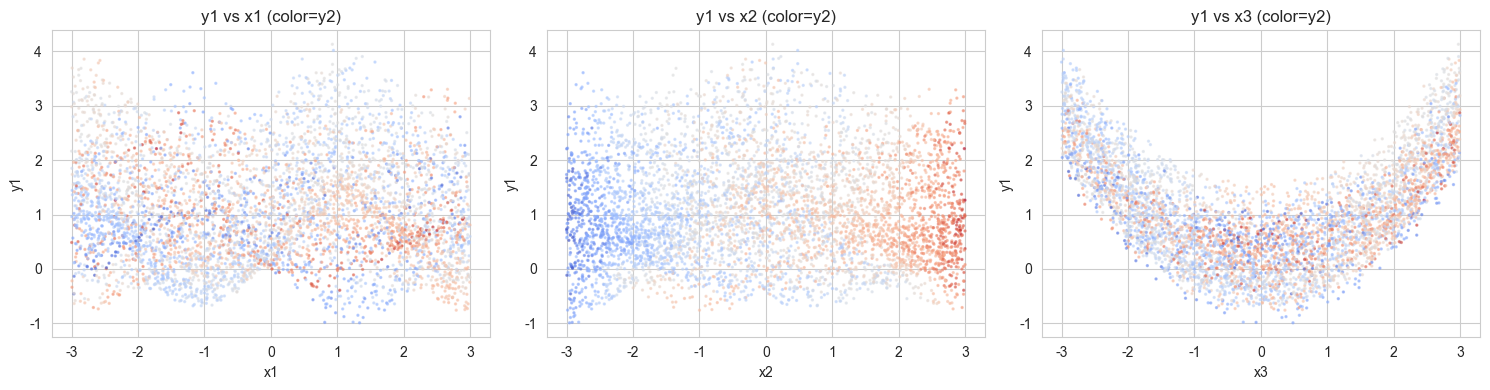

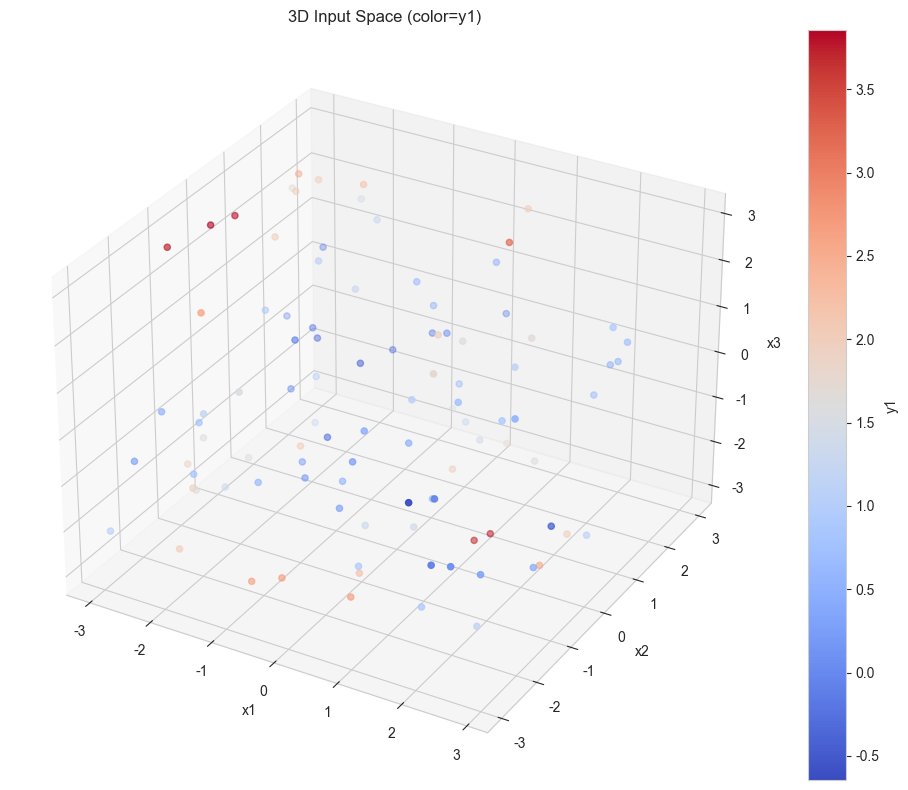

In [2]:
# ==================== 1. 生成合成非线性数据 ====================
np.random.seed(42); N = 5000
x1 = np.random.uniform(-3, 3, N); x2 = np.random.uniform(-3, 3, N); x3 = np.random.uniform(-3, 3, N)
y1 = np.sin(x1*1.5)*np.cos(x2*0.8) + x3**2*0.3 + np.exp(-np.abs(x2))*0.5 + np.sin(x1*x2*0.3)*0.4
y2 = np.cos(x3*1.2)*np.sin(x1*0.7) + x2**3*0.1 + np.tanh(x1+x2+x3)*0.6
y3 = np.sin(x1+x2)*np.cos(x3)*0.8 + np.abs(x1*x3)*0.15 + x2**2*0.2 + np.cos(x1*x2*x3*0.1)*0.3
for y in [y1,y2,y3]: y += np.random.normal(0, 0.05, N)
X = np.stack([x1,x2,x3],1).astype(np.float32); Y = np.stack([y1,y2,y3],1).astype(np.float32)
print(f'X: {X.shape}, Y: {Y.shape}')

# 数据可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, xi) in enumerate(zip(axes, [x1,x2,x3])):
    ax.scatter(xi, y1, c=y2, cmap='coolwarm', s=2, alpha=0.5)
    ax.set_xlabel(f'x{i+1}'); ax.set_ylabel('y1')
    ax.set_title(f'y1 vs x{i+1} (color=y2)')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '01_data_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

# 3D可视化
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x1[::50], x2[::50], x3[::50], c=y1[::50], cmap='coolwarm', s=20)
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_zlabel('x3')
ax.set_title('3D Input Space (color=y1)'); plt.colorbar(sc, label='y1')
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '01_3d_input.png'), dpi=150, bbox_inches='tight')
plt.show()


In [3]:
# ==================== 2. 数据预处理 ====================
scaler_X = StandardScaler(); scaler_Y = StandardScaler()
Xs = scaler_X.fit_transform(X); Ys = scaler_Y.fit_transform(Y)
X_tr, X_tmp, Y_tr, Y_tmp = train_test_split(Xs, Ys, test_size=0.3, random_state=42)
X_v, X_te, Y_v, Y_te = train_test_split(X_tmp, Y_tmp, test_size=0.5, random_state=42)
print(f'Train: {len(X_tr)} | Val: {len(X_v)} | Test: {len(X_te)}')

BATCH = 64
tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(Y_tr)), BATCH, True)
v_loader  = DataLoader(TensorDataset(torch.tensor(X_v), torch.tensor(Y_v)), BATCH, False)
te_loader  = DataLoader(TensorDataset(torch.tensor(X_te), torch.tensor(Y_te)), BATCH, False)


Train: 3500 | Val: 750 | Test: 750


In [4]:
# ==================== 3. 训练 MLP 回归器 ====================
print('=== MLP Regressor (3->128->128->64->3) ===')
mlp_r = get_model('mlp', 3, 3).to(DEVICE)
crit = nn.MSELoss(); opt = optim.Adam(mlp_r.parameters(), lr=0.001)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=10, factor=0.5)

hist_mlp = {'train_loss':[], 'val_loss':[]}
best_loss, best_st, wait = float('inf'), None, 0
for ep in range(200):
    mlp_r.train(); tl=0
    for x,y in tr_loader:
        x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad()
        loss=crit(mlp_r(x),y); loss.backward(); opt.step(); tl+=loss.item()
    tl/=len(tr_loader)
    mlp_r.eval(); vl=0
    with torch.no_grad():
        for x,y in v_loader: x,y=x.to(DEVICE),y.to(DEVICE); vl+=crit(mlp_r(x),y).item()
    vl/=len(v_loader); sched.step(vl)
    hist_mlp['train_loss'].append(tl); hist_mlp['val_loss'].append(vl)
    if vl<best_loss: best_loss=vl; best_st={k:v.cpu().clone() for k,v in mlp_r.state_dict().items()}; wait=0
    else: wait+=1
    if wait>=40: print(f'MLP early stop at {ep+1}'); break
    if (ep+1)%20==0: print(f'[MLP] E{ep+1:3d} | TL={tl:.4f} VL={vl:.4f}')
mlp_r.load_state_dict(best_st)

# Test R²
mlp_r.eval(); preds_mlp, truths = [], []
with torch.no_grad():
    for x,y in te_loader: x=x.to(DEVICE); preds_mlp.append(mlp_r(x).cpu().numpy()); truths.append(y.numpy())
preds_mlp = np.concatenate(preds_mlp); truths = np.concatenate(truths)
r2_mlp = r2_score(truths, preds_mlp, multioutput='uniform_average')
mse_mlp = mean_squared_error(truths, preds_mlp)
print(f'MLP Test R²={r2_mlp:.4f}, MSE={mse_mlp:.4f}')


=== MLP Regressor (3->128->128->64->3) ===
[MLP] E 20 | TL=0.0859 VL=0.0385
[MLP] E 40 | TL=0.0640 VL=0.0243
[MLP] E 60 | TL=0.0535 VL=0.0192
[MLP] E 80 | TL=0.0487 VL=0.0185
[MLP] E100 | TL=0.0450 VL=0.0161
[MLP] E120 | TL=0.0419 VL=0.0151
[MLP] E140 | TL=0.0402 VL=0.0133
[MLP] E160 | TL=0.0388 VL=0.0123
[MLP] E180 | TL=0.0396 VL=0.0125
MLP early stop at 198
MLP Test R²=0.9890, MSE=0.0106


In [5]:
# ==================== 4. 生成时序数据并训练 LSTM ====================
print('=== LSTM Regressor (seq_len=10, 3->64->64->1) ===')
# 生成时序数据
N2, SL = 5000, 10
t = np.linspace(0, 50, N2+SL)
s1 = np.sin(t*0.7)+0.5*np.sin(t*1.5)+np.random.normal(0,0.05,N2+SL)
s2 = np.cos(t*0.6)+0.3*np.sin(t*2.0)+np.random.normal(0,0.05,N2+SL)
s3 = np.sin(t*0.9+1.0)*np.cos(t*0.3)+np.random.normal(0,0.05,N2+SL)
target = np.sin(t*0.8)*np.cos(t*0.5)+np.exp(-0.1*t)*np.sin(t*1.2)+0.2*np.sin(t*2.1)*np.cos(t*0.4)

X_seq = np.stack([s1,s2,s3],1).astype(np.float32)
Y_seq = target.astype(np.float32)

# 滑动窗口
Xw, Yw = [], []
for i in range(N2):
    Xw.append(X_seq[i:i+SL]); Yw.append(Y_seq[i+SL])
Xw = np.array(Xw); Yw = np.array(Yw)

# 标准化时序数据
ns, sl, nf = Xw.shape
scaler_Xs = StandardScaler().fit(Xw.reshape(-1, nf))
Xws = scaler_Xs.transform(Xw.reshape(-1, nf)).reshape(ns, sl, nf)
scaler_Ys = StandardScaler().fit(Yw.reshape(-1,1))
Yws = scaler_Ys.transform(Yw.reshape(-1,1)).flatten()

X_tr_s, X_tmp_s, Y_tr_s, Y_tmp_s = train_test_split(Xws, Yws, test_size=0.3, random_state=42)
X_v_s, X_te_s, Y_v_s, Y_te_s = train_test_split(X_tmp_s, Y_tmp_s, test_size=0.5, random_state=42)

tr_loader_s = DataLoader(TensorDataset(torch.tensor(X_tr_s), torch.tensor(Y_tr_s).unsqueeze(1)), BATCH, True)
v_loader_s  = DataLoader(TensorDataset(torch.tensor(X_v_s), torch.tensor(Y_v_s).unsqueeze(1)), BATCH, False)
te_loader_s  = DataLoader(TensorDataset(torch.tensor(X_te_s), torch.tensor(Y_te_s).unsqueeze(1)), BATCH, False)

# 训练LSTM
lstm_r = get_model('lstm', 3, 1).to(DEVICE)
crit_s = nn.MSELoss(); opt_s = optim.Adam(lstm_r.parameters(), lr=0.001)
sched_s = optim.lr_scheduler.ReduceLROnPlateau(opt_s, mode='min', patience=10, factor=0.5)

hist_lstm = {'train_loss':[], 'val_loss':[]}
best_loss_s, best_st_s, wait_s = float('inf'), None, 0
for ep in range(200):
    lstm_r.train(); tl=0
    for x,y in tr_loader_s:
        x,y=x.to(DEVICE),y.to(DEVICE); opt_s.zero_grad()
        loss=crit_s(lstm_r(x),y); loss.backward(); opt_s.step(); tl+=loss.item()
    tl/=len(tr_loader_s)
    lstm_r.eval(); vl=0
    with torch.no_grad():
        for x,y in v_loader_s: x,y=x.to(DEVICE),y.to(DEVICE); vl+=crit_s(lstm_r(x),y).item()
    vl/=len(v_loader_s); sched_s.step(vl)
    hist_lstm['train_loss'].append(tl); hist_lstm['val_loss'].append(vl)
    if vl<best_loss_s: best_loss_s=vl; best_st_s={k:v.cpu().clone() for k,v in lstm_r.state_dict().items()}; wait_s=0
    else: wait_s+=1
    if wait_s>=40: print(f'LSTM early stop at {ep+1}'); break
    if (ep+1)%20==0: print(f'[LSTM] E{ep+1:3d} | TL={tl:.4f} VL={vl:.4f}')
lstm_r.load_state_dict(best_st_s)

# Test R²
lstm_r.eval(); preds_lstm, truths_s = [], []
with torch.no_grad():
    for x,y in te_loader_s: x=x.to(DEVICE); preds_lstm.append(lstm_r(x).cpu().numpy()); truths_s.append(y.numpy())
preds_lstm = np.concatenate(preds_lstm); truths_s = np.concatenate(truths_s)
r2_lstm = r2_score(truths_s, preds_lstm)
mse_lstm = mean_squared_error(truths_s, preds_lstm)
print(f'LSTM Test R²={r2_lstm:.4f}, MSE={mse_lstm:.4f}')


=== LSTM Regressor (seq_len=10, 3->64->64->1) ===
[LSTM] E 20 | TL=0.2612 VL=0.2565
[LSTM] E 40 | TL=0.1190 VL=0.1145
[LSTM] E 60 | TL=0.0959 VL=0.0823
[LSTM] E 80 | TL=0.0525 VL=0.0679
[LSTM] E100 | TL=0.0379 VL=0.0528
[LSTM] E120 | TL=0.0299 VL=0.0517
[LSTM] E140 | TL=0.0309 VL=0.0441
[LSTM] E160 | TL=0.0224 VL=0.0307
[LSTM] E180 | TL=0.0207 VL=0.0323
[LSTM] E200 | TL=0.0181 VL=0.0271
LSTM Test R²=0.9650, MSE=0.0367


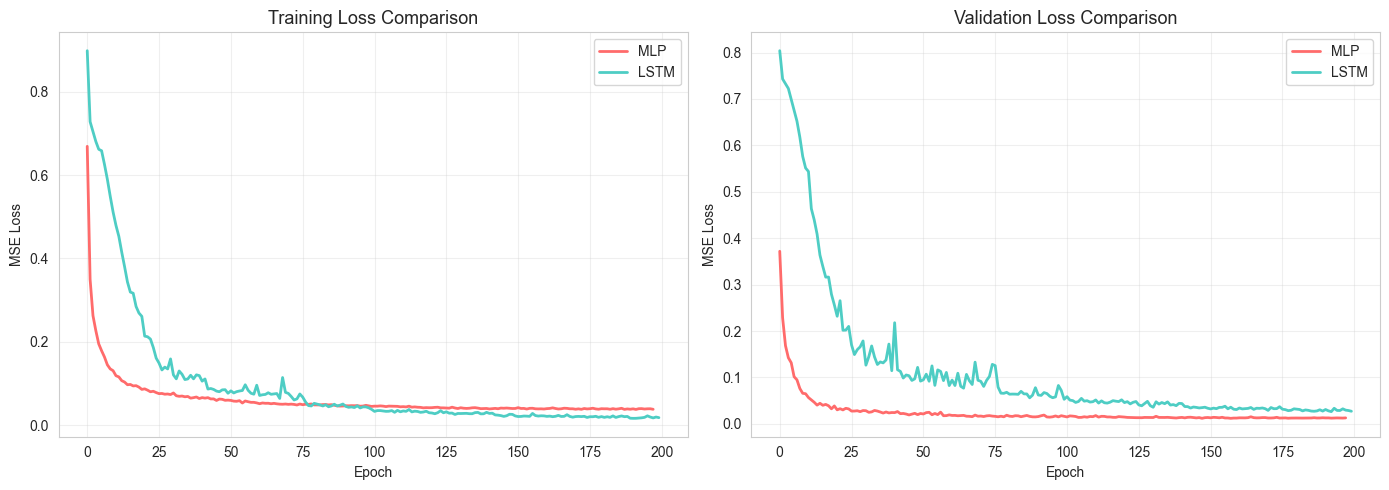

In [6]:
# ==================== 5. 训练Loss曲线对比 ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, key, title in [(axes[0], 'train_loss', 'Training Loss'), (axes[1], 'val_loss', 'Validation Loss')]:
    ax.plot(hist_mlp[key], label='MLP', color='#FF6B6B', linewidth=2)
    ax.plot(hist_lstm[key], label='LSTM', color='#4ECDC4', linewidth=2)
    ax.set_title(f'{title} Comparison', fontsize=13); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '02_training_loss.png'), dpi=150, bbox_inches='tight')
plt.show()


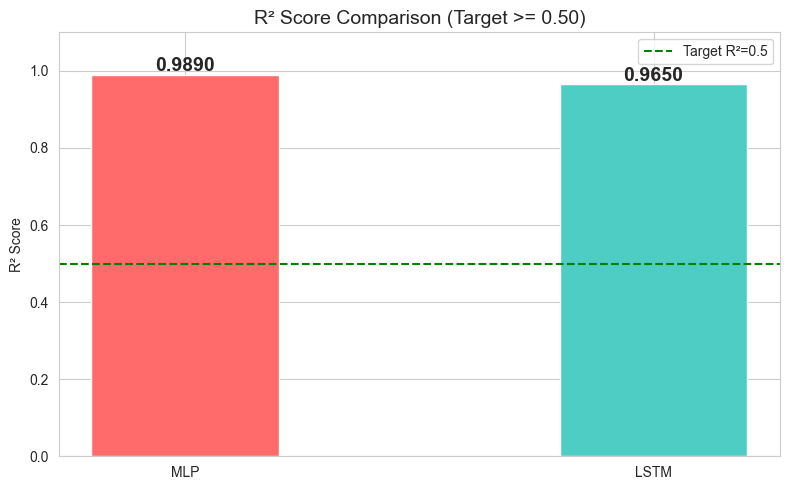

In [8]:
# ==================== 6. R² 对比柱状图 ====================
fig, ax = plt.subplots(figsize=(8, 5))
models_r = ['MLP', 'LSTM']
r2s = [r2_mlp, r2_lstm]
bars = ax.bar(models_r, r2s, color=['#FF6B6B','#4ECDC4'], edgecolor='white', width=0.4)
for b, v in zip(bars, r2s): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=14)
ax.axhline(y=0.5, color='green', linestyle='--', label='Target R²=0.5'); ax.legend()
ax.set_ylabel('R² Score'); ax.set_title('R² Score Comparison (Target >= 0.50)', fontsize=14); ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '03_r2_compare.png'), dpi=150, bbox_inches='tight')
plt.show()


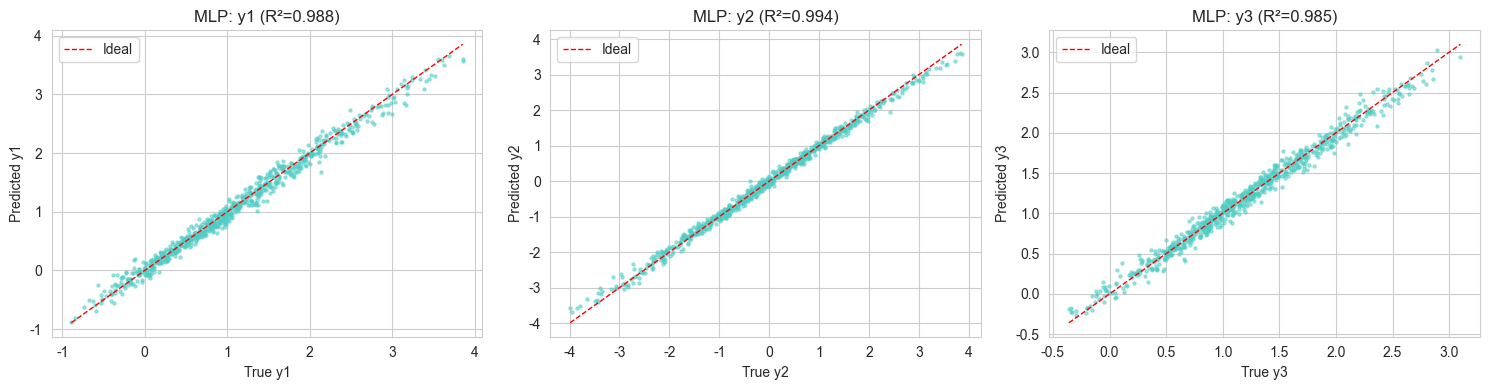

In [9]:
# ==================== 7. 预测 vs 真实值散点图 (MLP) ====================
Y_pred_orig = scaler_Y.inverse_transform(preds_mlp)
Y_true_orig = scaler_Y.inverse_transform(truths)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.scatter(Y_true_orig[:,i], Y_pred_orig[:,i], c='#4ECDC4', s=5, alpha=0.5)
    ax.plot([Y_true_orig[:,i].min(), Y_true_orig[:,i].max()],
            [Y_true_orig[:,i].min(), Y_true_orig[:,i].max()], 'r--', lw=1, label='Ideal')
    ax.set_xlabel(f'True y{i+1}'); ax.set_ylabel(f'Predicted y{i+1}')
    ax.set_title(f'MLP: y{i+1} (R²={r2_score(Y_true_orig[:,i], Y_pred_orig[:,i]):.3f})'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '04_pred_vs_true.png'), dpi=150, bbox_inches='tight')
plt.show()


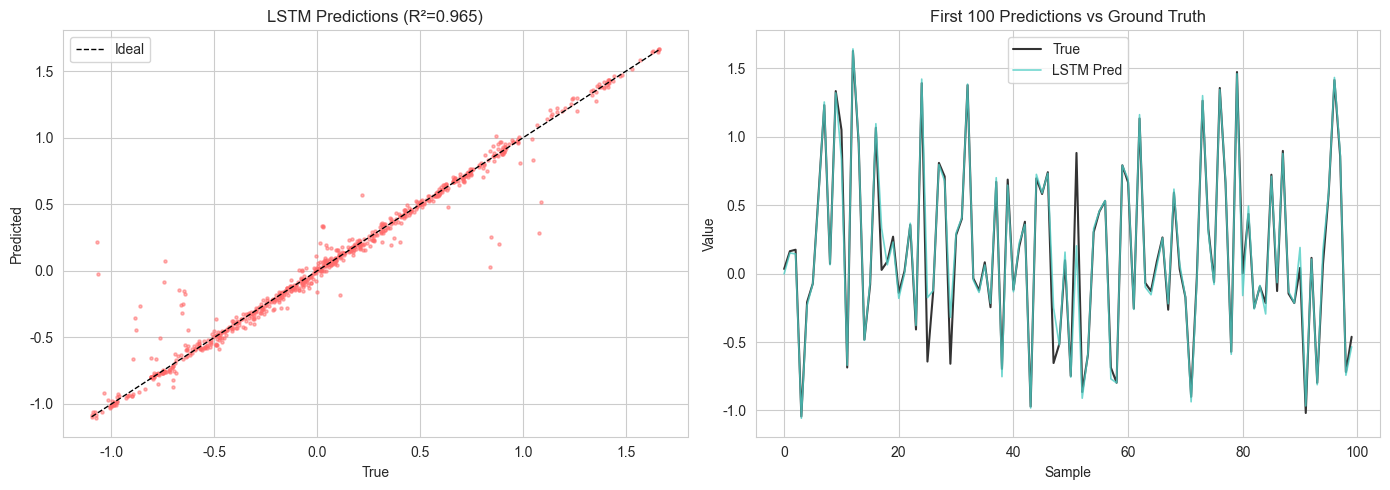

In [10]:
# ==================== 8. LSTM预测 vs 真实值 ====================
Y_pred_lstm_orig = scaler_Ys.inverse_transform(preds_lstm.reshape(-1,1)).flatten()
Y_true_lstm_orig = scaler_Ys.inverse_transform(truths_s.reshape(-1,1)).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 散点图
axes[0].scatter(Y_true_lstm_orig, Y_pred_lstm_orig, c='#FF6B6B', s=5, alpha=0.5)
axes[0].plot([Y_true_lstm_orig.min(), Y_true_lstm_orig.max()],
             [Y_true_lstm_orig.min(), Y_true_lstm_orig.max()], 'k--', lw=1, label='Ideal')
axes[0].set_xlabel('True'); axes[0].set_ylabel('Predicted'); axes[0].set_title(f'LSTM Predictions (R²={r2_lstm:.3f})')
axes[0].legend()

# 前100点时间序列
axes[1].plot(Y_true_lstm_orig[:100], label='True', color='#333333', linewidth=1.5)
axes[1].plot(Y_pred_lstm_orig[:100], label='LSTM Pred', color='#4ECDC4', linewidth=1.2, alpha=0.8)
axes[1].set_xlabel('Sample'); axes[1].set_ylabel('Value')
axes[1].set_title('First 100 Predictions vs Ground Truth'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints', '05_lstm_results.png'), dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# ==================== 9. 保存模型 ====================
CKPT = os.path.join(ROOT, 'backend', 'regression_model', 'checkpoints')
torch.save({
    'mlp_state_dict': {k:v.cpu().clone() for k,v in mlp_r.state_dict().items()},
    'lstm_state_dict': {k:v.cpu().clone() for k,v in lstm_r.state_dict().items()},
    'r2_mlp': r2_mlp, 'r2_lstm': r2_lstm,
    'scaler_X_mlp': scaler_X, 'scaler_Y_mlp': scaler_Y,
    'scaler_X_lstm': scaler_Xs, 'scaler_Y_lstm': scaler_Ys,
}, os.path.join(CKPT, 'best_model.pth'))
print(f'Saved. MLP R²={r2_mlp:.4f} | LSTM R²={r2_lstm:.4f}')


Saved. MLP R²=0.9890 | LSTM R²=0.9650
